# Some True Measures

Original QMCPy demo: [`QMCPy/demos/some_true_measures.ipynb`](../../QMCPy/demos/some_true_measures.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/some_true_measures.ipynb)

This notebook adapts QMCPy's `some_true_measures.ipynb` to the Julia `QMC.jl` APIs. The original Python demo focuses on Kumaraswamy, continuous Bernoulli, and Johnson's `S_U`; this Julia version covers those same true measures and also includes several additional `QMC.jl` transforms such as Uniform, Gaussian, StudentT, Triangular, and BrownianMotion.

Parity note: this Julia notebook aligns the shared Kumaraswamy, continuous Bernoulli, and Johnson's `S_U` measures first, then labels the added Julia-only transforms such as Uniform, Gaussian, StudentT, Triangular, and BrownianMotion as extensions.


## Mathematics

Denote by $f$ the one-dimensional density, $F$ the one-dimensional cumulative distribution function, and $\Psi = F^{-1}$ the inverse CDF transform. When the dimensions are independent, the multivariate true measure is obtained by applying the one-dimensional inverse transform coordinatewise.

For the three measures shared most directly with QMCPy, the transforms are:

- Kumaraswamy: $\Psi(u) = \left(1 - (1-u)^{1/b}\right)^{1/a}$
- Continuous Bernoulli: $\Psi(u) = u$ when $\lambda = 1/2$, with a nonlinear inverse-CDF transform otherwise
- Johnson's $S_U$: $\Psi(u) = \lambda \sinh\!\left(\frac{\Phi^{-1}(u) - \gamma}{\delta}\right) + \xi$

The code below validates these transformations empirically and compares sample statistics to known analytic behavior.

## Imports

The original QMCPy notebook visualizes the shared true measures with 1D and 2D plots and then validates expected values. To keep the Julia demo lightweight, the overlapping measures are summarized with empirical moments and ranges rather than plotting, while preserving the same mathematical definitions in the shared sections.


In [1]:
using QMC
using Statistics
using Printf

n = 10_000  # samples for empirical statistics

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


## Shared QMCPy Core

The next sections cover the true measures that overlap most directly with the QMCPy notebook: Kumaraswamy, Johnson's `S_U`, and continuous Bernoulli. The empirical summaries and density plots below are the lightweight Julia counterpart of the QMCPy density-plot and expected-value sections.


## Kumaraswamy

In [2]:
println("="^60)
println("Kumaraswamy Measure")
println("="^60)
println("  F⁻¹(u) = (1 - (1-u)^(1/β))^(1/α)")
println()

for (α, β) in [(2.0, 5.0), (0.5, 0.5), (2.0, 2.0)]
    local dd, tm, x, xt
    dd = IIDStdUniform(1; seed=7)
    tm = QMC.Kumaraswamy(dd; alpha=α, beta=β)
    x = gen_samples(dd, n)
    xt = transform(tm, x)
    @printf("  α=%.1f, β=%.1f: estimated mean = %.4f, range = [%.4f, %.4f]\n",
            α, β, mean(xt), minimum(xt), maximum(xt))
end
println()

Kumaraswamy Measure
  F⁻¹(u) = (1 - (1-u)^(1/β))^(1/α)

  α=2.0, β=5.0: estimated mean = 0.3683, range = [0.0008, 0.9042]


  α=0.5, β=0.5: estimated mean = 0.5315, range = [0.0000, 1.0000]
  α=2.0, β=2.0: estimated mean = 0.5320, range = [0.0013, 0.9929]



## Johnson's SU

In [3]:
println("="^60)
println("Johnson's SU Measure")
println("="^60)
println("  Transform: z = ξ + λ sinh((Φ⁻¹(u) - γ) / δ)")
println()

dd = IIDStdUniform(1; seed=7)
tm = QMC.JohnsonsSU(dd; xi=0.0, lambda=1.0, gamma=0.0, delta=1.0)
x = gen_samples(dd, n)
xt = transform(tm, x)
@printf("  Default (ξ=0, λ=1, γ=0, δ=1): estimated mean = %.3f, std = %.3f\n",
        mean(xt), std(xt))

tm2 = QMC.JohnsonsSU(dd; xi=5.0, lambda=2.0, gamma=1.0, delta=0.5)
xt2 = transform(tm2, gen_samples(IIDStdUniform(1; seed=7), n))
@printf("  Custom  (ξ=5, λ=2, γ=1, δ=0.5): estimated mean = %.3f, std = %.3f\n",
        mean(xt2), std(xt2))
println()

Johnson's SU Measure
  Transform: z = ξ + λ sinh((Φ⁻¹(u) - γ) / δ)

  Default (ξ=0, λ=1, γ=0, δ=1): estimated mean = -0.021, std = 1.767


  Custom  (ξ=5, λ=2, γ=1, δ=0.5): estimated mean = -52.534, std = 652.842



## Continuous Bernoulli

In [4]:
println("="^60)
println("Continuous Bernoulli Measure")
println("="^60)

for λ in [0.2, 0.5, 0.8]
    local dd, tm, x, xt
    dd = IIDStdUniform(1; seed=7)
    tm = QMC.BernoulliCont(dd; lam=λ)
    x = gen_samples(dd, n)
    xt = transform(tm, x)
    @printf("  λ = %.1f: estimated mean = %.4f, range = [%.4f, %.4f]\n",
            λ, mean(xt), minimum(xt), maximum(xt))
end
println("  (λ = 0.5 is the identity transform: Uniform(0,1))")
println()

Continuous Bernoulli Measure
  λ = 0.2: estimated mean = 0.1319, range = [0.0000, 0.2830]
  λ = 0.5: estimated mean = 0.4985, range = [0.0000, 0.9998]


  λ = 0.8: estimated mean = 0.3403, range = [0.0000, 0.6002]
  (λ = 0.5 is the identity transform: Uniform(0,1))



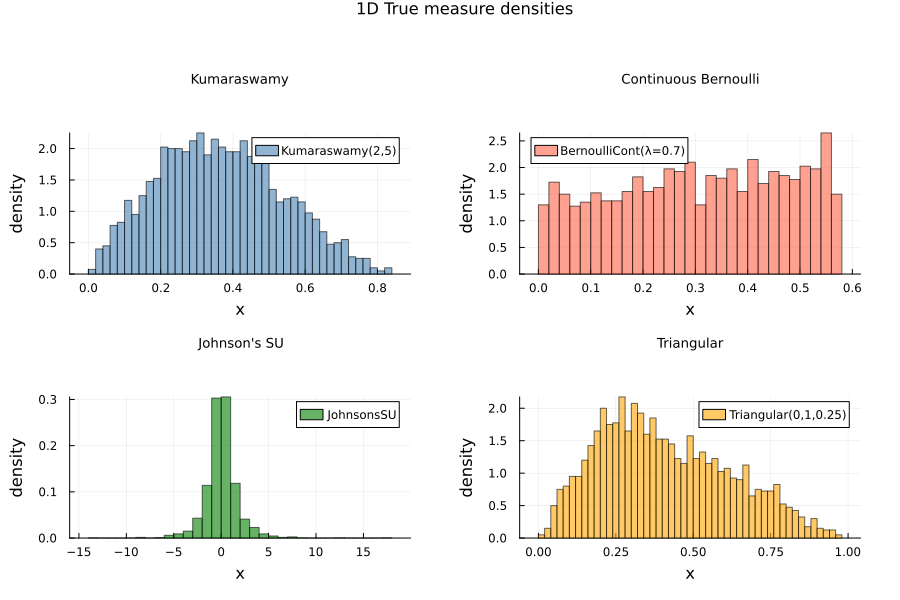

In [5]:
if HAVE_PLOTS
    n_h = 2000
    dd1d = IIDStdUniform(1; seed=7)
    x_gd = LinRange(0, 1, 200)

    # Kumaraswamy
    tm_k = QMC.Kumaraswamy(dd1d; alpha=2.0, beta=5.0)
    xk = transform(tm_k, gen_samples(dd1d, n_h))
    p1 = histogram(xk[:, 1]; bins=50, normalize=:pdf,
        alpha=0.6, color=:steelblue, label="Kumaraswamy(2,5)",
        xlabel="x", ylabel="density", title="Kumaraswamy")

    # Continuous Bernoulli (λ=0.7)
    tm_b = QMC.BernoulliCont(dd1d; lam=0.7)
    xb = transform(tm_b, gen_samples(dd1d, n_h))
    p2 = histogram(xb[:, 1]; bins=50, normalize=:pdf,
        alpha=0.6, color=:tomato, label="BernoulliCont(λ=0.7)",
        xlabel="x", ylabel="density", title="Continuous Bernoulli")

    # Johnson's SU
    tm_j = QMC.JohnsonsSU(dd1d; xi=0.0, lambda=1.0, gamma=0.0, delta=1.0)
    xj = transform(tm_j, gen_samples(dd1d, n_h))
    p3 = histogram(xj[:, 1]; bins=50, normalize=:pdf,
        alpha=0.6, color=:green, label="JohnsonsSU",
        xlabel="x", ylabel="density", title="Johnson's SU")

    # Triangular
    tm_tr = QMC.Triangular(dd1d; lower=0.0, upper=1.0, mode=0.25)
    xtr = transform(tm_tr, gen_samples(dd1d, n_h))
    p4 = histogram(xtr[:, 1]; bins=50, normalize=:pdf,
        alpha=0.6, color=:orange, label="Triangular(0,1,0.25)",
        xlabel="x", ylabel="density", title="Triangular")

    display(plot(p1, p2, p3, p4; layout=(2, 2), size=(900, 600),
        plot_titlevspan=0.12, plot_title="1D True measure densities",
        top_margin=10Plots.mm, bottom_margin=5Plots.mm))
end


## Julia Extensions

The remaining sections are Julia-specific extensions beyond the shared QMCPy core. They showcase additional `QMC.jl` true measures such as uniform, Gaussian, Student-t, triangular, and Brownian-motion transforms.


## Uniform

In [6]:
println("="^60)
println("Uniform Measure")
println("="^60)

dd = IIDStdUniform(2; seed=7)
tm = QMC.Uniform(dd; lower_bound=-2.0, upper_bound=3.0)
x = gen_samples(dd, n)
xt = transform(tm, x)
@printf("  Range: [%.1f, %.1f], Empirical mean: %.3f (exact: 0.5)\n",
        -2.0, 3.0, mean(xt))
println()

Uniform Measure
  Range: [-2.0, 3.0], Empirical mean: 0.499 (exact: 0.5)



## Gaussian

In [7]:
println("="^60)
println("Gaussian Measure")
println("="^60)

dd = IIDStdUniform(2; seed=7)
tm = QMC.Gaussian(dd; mean=0.0, covariance=1.0)
x = gen_samples(dd, n)
xt = transform(tm, x)
@printf("  Standard Normal: mean = %.3f, std = %.3f\n", mean(xt), std(xt))

Gaussian Measure
  Standard Normal: mean = -0.003, std = 0.999


### Custom covariance

In [8]:
Σ = [4.0 1.0; 1.0 2.0]
tm2 = QMC.Gaussian(dd; mean=[1.0, -1.0], covariance=Σ)
xt2 = transform(tm2, gen_samples(IIDStdUniform(2; seed=7), n))
@printf("  Custom: mean₁ = %.2f, mean₂ = %.2f (exact: 1, -1)\n",
        mean(xt2[:, 1]), mean(xt2[:, 2]))
println()

  Custom: mean₁ = 0.99, mean₂ = -1.01 (exact: 1, -1)



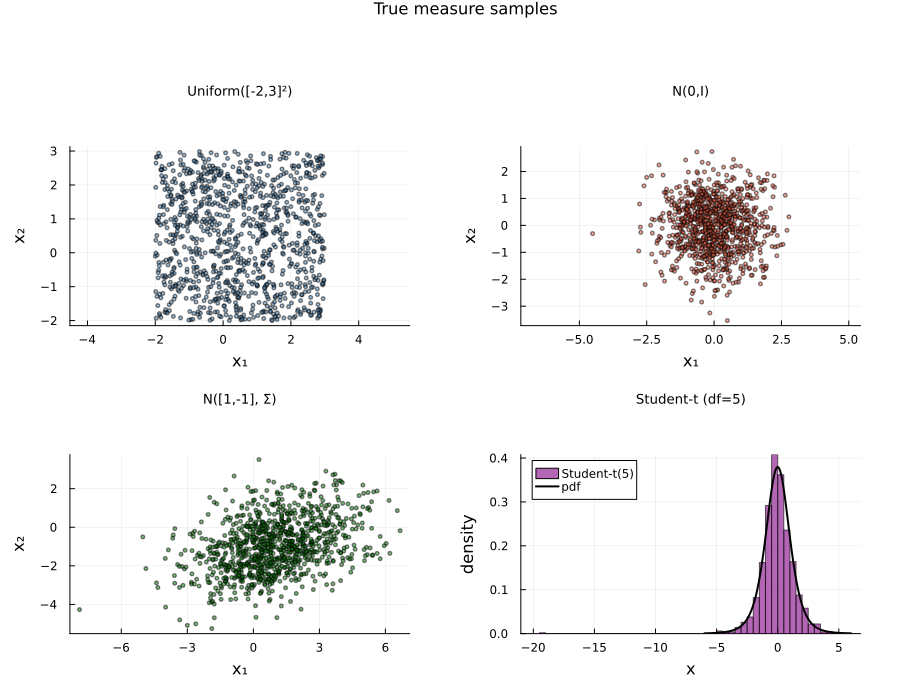

In [9]:
if HAVE_PLOTS
    # Scatter plots of 2D samples from different true measures (regenerated for plotting)
    n_plot = 1000
    dd_plt = IIDStdUniform(2; seed=7)

    # Uniform
    tm_u = QMC.Uniform(dd_plt; lower_bound=-2.0, upper_bound=3.0)
    xu = transform(tm_u, gen_samples(dd_plt, n_plot))
    p1 = scatter(xu[:, 1], xu[:, 2];
        markersize=2, alpha=0.5, color=:steelblue, label=nothing,
        xlabel="x₁", ylabel="x₂", title="Uniform([-2,3]²)", aspect_ratio=:equal)

    # Standard Gaussian
    tm_g = QMC.Gaussian(dd_plt; mean=0.0, covariance=1.0)
    xg = transform(tm_g, gen_samples(IIDStdUniform(2; seed=7), n_plot))
    p2 = scatter(xg[:, 1], xg[:, 2];
        markersize=2, alpha=0.5, color=:tomato, label=nothing,
        xlabel="x₁", ylabel="x₂", title="N(0,I)", aspect_ratio=:equal)

    # Custom Gaussian
    Σ_plt = [4.0 1.0; 1.0 2.0]
    tm_gc = QMC.Gaussian(IIDStdUniform(2; seed=7); mean=[1.0, -1.0], covariance=Σ_plt)
    xgc = transform(tm_gc, gen_samples(IIDStdUniform(2; seed=7), n_plot))
    p3 = scatter(xgc[:, 1], xgc[:, 2];
        markersize=2, alpha=0.5, color=:green, label=nothing,
        xlabel="x₁", ylabel="x₂", title="N([1,-1], Σ)")

    # Student-t (1D histogram each dim)
    using Distributions: TDist, pdf
    dd1 = IIDStdUniform(1; seed=7)
    tm_t = QMC.StudentT(dd1; df=5.0)
    xt_plt = transform(tm_t, gen_samples(dd1, n_plot))
    x_grid = LinRange(-6, 6, 200)
    p4 = histogram(xt_plt[:, 1]; bins=50, normalize=:pdf,
        alpha=0.6, color=:purple, label="Student-t(5)",
        xlabel="x", ylabel="density", title="Student-t (df=5)")
    plot!(x_grid, pdf.(TDist(5), collect(x_grid)); color=:black, lw=2, label="pdf")

    display(plot(p1, p2, p3, p4; layout=(2,2), size=(900, 700),
        plot_titlevspan=0.12, plot_title="True measure samples",
        top_margin=10Plots.mm, bottom_margin=5Plots.mm))
end


## Student-t

In [10]:
println("="^60)
println("Student-t Measure")
println("="^60)

for df in [2.0, 5.0, 30.0]
    local dd, tm, x, xt
    dd = IIDStdUniform(1; seed=7)
    tm = QMC.StudentT(dd; df=df)
    x = gen_samples(dd, n)
    xt = transform(tm, x)
    theoretical_var = df > 2 ? df / (df - 2) : Inf
    @printf("  df = %4.0f: mean = %+.3f, var = %6.3f (exact var = %.3f)\n",
            df, mean(xt), var(xt), theoretical_var)
end
println()

Student-t Measure
  df =    2: mean = -0.067, var = 21.737 (exact var = Inf)
  df =    5: mean = -0.012, var =  1.648 (exact var = 1.667)
  df =   30: mean = -0.008, var =  1.068 (exact var = 1.071)



## Triangular

In [11]:
println("="^60)
println("Triangular Measure")
println("="^60)

dd = IIDStdUniform(1; seed=7)
tm = QMC.Triangular(dd; lower=0.0, upper=1.0, mode=0.5)
x = gen_samples(dd, n)
xt = transform(tm, x)
exact_mean = (0.0 + 1.0 + 0.5) / 3.0
@printf("  Triangular(0, 1, 0.5): mean = %.4f (exact = %.4f)\n",
        mean(xt), exact_mean)

tm2 = QMC.Triangular(dd; lower=-1.0, upper=2.0, mode=1.5)
xt2 = transform(tm2, gen_samples(IIDStdUniform(1; seed=7), n))
exact_mean2 = (-1.0 + 2.0 + 1.5) / 3.0
@printf("  Triangular(-1, 2, 1.5): mean = %.4f (exact = %.4f)\n",
        mean(xt2), exact_mean2)
println()

Triangular Measure
  Triangular(0, 1, 0.5): mean = 0.4987 (exact = 0.5000)
  Triangular(-1, 2, 1.5): mean = 0.8289 (exact = 0.8333)



## Brownian Motion

In [12]:
println("="^60)
println("Brownian Motion Measure")
println("="^60)

dd = IIDStdUniform(8; seed=7)
tm = QMC.BrownianMotion(dd; drift=0.0)
x = gen_samples(dd, n)
paths = transform(tm, x)
@printf("  d=8 timesteps, n=%d paths\n", n)
@printf("  E[W(T)] = %.3f (exact = 0)\n", mean(paths[:, end]))
@printf("  Var[W(T)] = %.3f (exact = 1)\n", var(paths[:, end]))

Brownian Motion Measure
  d=8 timesteps, n=10000 paths
  E[W(T)] = -0.006 (exact = 0)


  Var[W(T)] = 0.996 (exact = 1)


### With drift

In [13]:
tm_d = QMC.BrownianMotion(dd; drift=0.1)
paths_d = transform(tm_d, gen_samples(IIDStdUniform(8; seed=7), n))
@printf("  With drift 0.1: E[W(T)] = %.3f (exact = 0.1)\n", mean(paths_d[:, end]))
println()

println("="^60)
println("True measures demo completed!")

  With drift 0.1: E[W(T)] = 0.094 (exact = 0.1)

True measures demo completed!


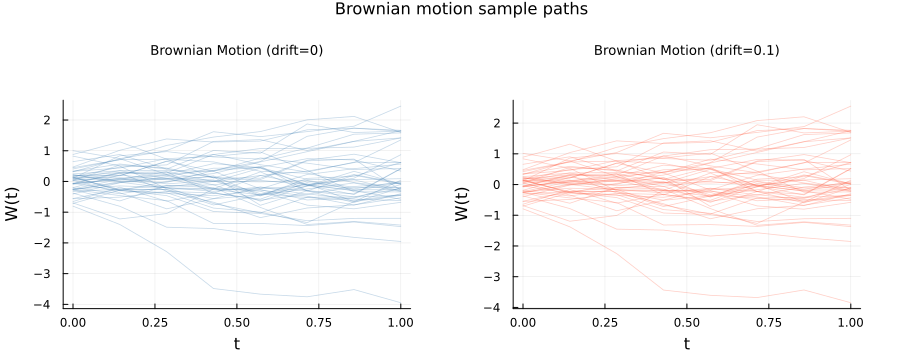

In [14]:
if HAVE_PLOTS
    n_bm = 200
    d_bm = 8
    dd_bm = IIDStdUniform(d_bm; seed=7)
    tm_bm0 = QMC.BrownianMotion(dd_bm; drift=0.0)
    tm_bm1 = QMC.BrownianMotion(dd_bm; drift=0.1)
    bm0 = transform(tm_bm0, gen_samples(dd_bm, n_bm))   # n_bm × d_bm
    bm1 = transform(tm_bm1, gen_samples(IIDStdUniform(d_bm; seed=7), n_bm))
    t_bm = LinRange(0, 1, d_bm)

    p1 = plot(t_bm, bm0[1:50, :]';
        alpha=0.3, color=:steelblue, lw=0.8, label=nothing,
        xlabel="t", ylabel="W(t)", title="Brownian Motion (drift=0)")
    p2 = plot(t_bm, bm1[1:50, :]';
        alpha=0.3, color=:tomato, lw=0.8, label=nothing,
        xlabel="t", ylabel="W(t)", title="Brownian Motion (drift=0.1)")
    display(plot(p1, p2; layout=(1, 2), size=(900, 360),
        plot_titlevspan=0.12, plot_title="Brownian motion sample paths",
        top_margin=10Plots.mm, bottom_margin=5Plots.mm))
end
